# 07 — Post-method train/test splits

Split subjects after TEMPTED and MEFISTO have already been fit to the full cohort.

The split therefore tests how well the learned latent representations predict country in held-out subjects. It does not test a fully held-out decomposition pipeline because both methods were fit before the split.

TEMPTED uses its native subject component scores. MEFISTO uses the subject scores saved in notebook 04, which are simple averages of each subject's sample-level factor scores.


In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

N_SPLITS = 100
TEST_SIZE = .20
SEED = 2026

root = Path(".") if Path("data").exists() else Path("..")
prep = sorted((root / "data" / "preprocessing").iterdir())[-1]
t_dir = sorted((root / "data" / "tempted").iterdir())[-1]
m_dir = sorted((root / "data" / "mefisto").iterdir())[-1]
output = root / "data" / "train_test" / datetime.now().strftime("%Y%m%d_%H%M%S")
figures = output / "figures"
figures.mkdir(parents=True)

# load subject scores and country
metadata = pd.read_csv(prep / "metadata.csv", dtype={"subject_id": str})
tempted = pd.read_csv(t_dir / "subject_scores.csv", dtype={"subject_id": str})
mefisto = pd.read_csv(m_dir / "subject_scores.csv", dtype={"subject_id": str})

country = metadata[["subject_id", "country"]].drop_duplicates("subject_id")

tempted = tempted.merge(country, on="subject_id")
mefisto = mefisto.merge(country, on="subject_id")

countries = ["FIN", "EST", "RUS"]
colors = {
    "FIN": "green",
    "EST": "blue",
    "RUS": "red",
}

tempted = tempted[tempted["country"].isin(countries)]
mefisto = mefisto[mefisto["country"].isin(countries)]

t_dims = [c for c in tempted if c.startswith("component_")]
m_dims = [c for c in mefisto if c.startswith("factor_")]


In [2]:
# keep the same subjects in the same order for both methods

subjects = (
    tempted[["subject_id", "country"]]
    .merge(mefisto[["subject_id"]], on="subject_id")
)

tempted = subjects.merge(
    tempted[["subject_id"] + t_dims],
    on="subject_id",
)

mefisto = subjects.merge(
    mefisto[["subject_id"] + m_dims],
    on="subject_id",
)

print(
    len(subjects),
    "subjects |",
    subjects["country"].value_counts().to_dict(),
)


209 subjects | {'EST': 71, 'FIN': 69, 'RUS': 69}


## Repeated subject-level splits

Use the same 100 stratified 80/20 subject splits for both methods. The classifier is fit only after the split. Balanced accuracy is the main score because it gives each country equal weight.


In [3]:
# make repeated stratified subject splits

splitter = StratifiedShuffleSplit(
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    random_state=SEED,
)

scores = []
predictions = []
first_split = None

frames = [
    ("TEMPTED", tempted, t_dims),
    ("MEFISTO", mefisto, m_dims),
]

for split, (train_index, test_index) in enumerate(
    splitter.split(subjects, subjects["country"]),
    start=1,
):
    if split == 1:
        first_split = (train_index, test_index)

    for method, frame, dims in frames:
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000),
        )

        x_train = frame.iloc[train_index][dims]
        y_train = frame.iloc[train_index]["country"]
        x_test = frame.iloc[test_index][dims]
        y_test = frame.iloc[test_index]["country"]

        model.fit(x_train, y_train)

        train_prediction = model.predict(x_train)
        test_prediction = model.predict(x_test)

        scores.append([
            method,
            split,
            "train",
            accuracy_score(y_train, train_prediction),
            balanced_accuracy_score(y_train, train_prediction),
        ])

        scores.append([
            method,
            split,
            "test",
            accuracy_score(y_test, test_prediction),
            balanced_accuracy_score(y_test, test_prediction),
        ])

        for subject_id, actual, predicted in zip(
            frame.iloc[test_index]["subject_id"],
            y_test,
            test_prediction,
        ):
            predictions.append([
                method,
                split,
                subject_id,
                actual,
                predicted,
            ])

scores = pd.DataFrame(
    scores,
    columns=[
        "method",
        "split",
        "set",
        "accuracy",
        "balanced_accuracy",
    ],
)

predictions = pd.DataFrame(
    predictions,
    columns=[
        "method",
        "split",
        "subject_id",
        "actual_country",
        "predicted_country",
    ],
)

# save split results
scores.to_csv(output / "split_scores.csv", index=False)
predictions.to_csv(output / "test_predictions.csv", index=False)

print("Saved:", output)
scores[scores["set"] == "test"].groupby("method")[["accuracy", "balanced_accuracy"]].mean()


Saved: ../data/train_test/20260812_170029


,accuracy,balanced_accuracy
method,,
MEFISTO,0.500714,0.500714
TEMPTED,0.514286,0.514286


In [4]:
# save a figure

def save(name):
    plt.tight_layout()
    plt.savefig(figures / name, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


## Split visualizations

The first two plots show the first train/test split directly in each subject-level latent space. The score plot summarizes variability across all 100 held-out splits, and the confusion matrices summarize the held-out country predictions.


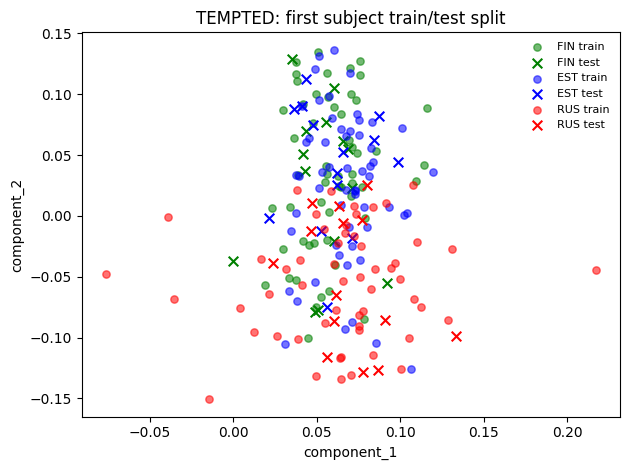

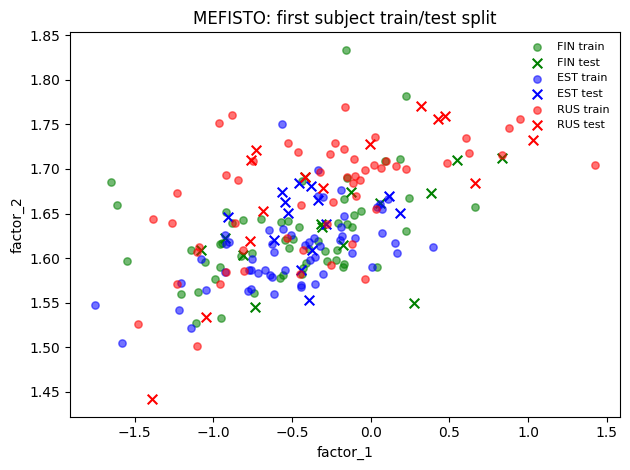

In [5]:
# show the first split in each subject-level latent space

train_index, test_index = first_split

for method, frame, dims in frames:
    for country in countries:
        train = frame.iloc[train_index]
        test = frame.iloc[test_index]

        train = train[train["country"] == country]
        test = test[test["country"] == country]

        plt.scatter(
            train[dims[0]],
            train[dims[1]],
            s=28,
            alpha=.55,
            color=colors[country],
            label=f"{country} train",
        )

        plt.scatter(
            test[dims[0]],
            test[dims[1]],
            s=48,
            marker="x",
            color=colors[country],
            label=f"{country} test",
        )

    plt.xlabel(dims[0])
    plt.ylabel(dims[1])
    plt.legend(frameon=False, fontsize=8)
    plt.title(f"{method}: first subject train/test split")
    save(f"{method.lower()}_first_split.png")


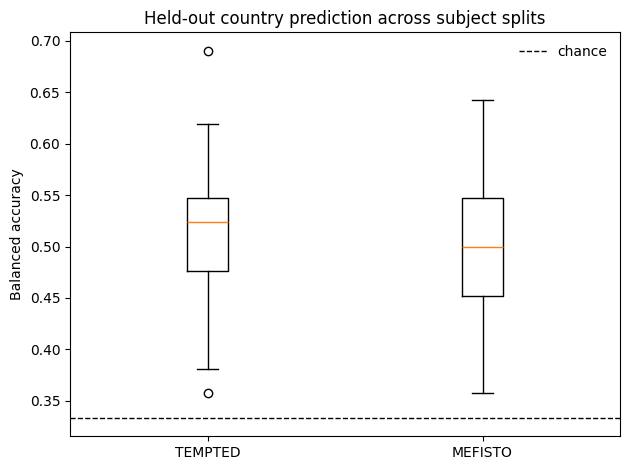

In [6]:
# compare held-out balanced accuracy across splits

test_scores = scores[scores["set"] == "test"]

values = [
    test_scores.loc[test_scores["method"] == method, "balanced_accuracy"]
    for method in ["TEMPTED", "MEFISTO"]
]

plt.boxplot(
    values,
    tick_labels=["TEMPTED", "MEFISTO"],
)

plt.axhline(
    1 / len(countries),
    color="black",
    linestyle="--",
    linewidth=1,
    label="chance",
)

plt.ylabel("Balanced accuracy")
plt.title("Held-out country prediction across subject splits")
plt.legend(frameon=False)
save("test_balanced_accuracy.png")


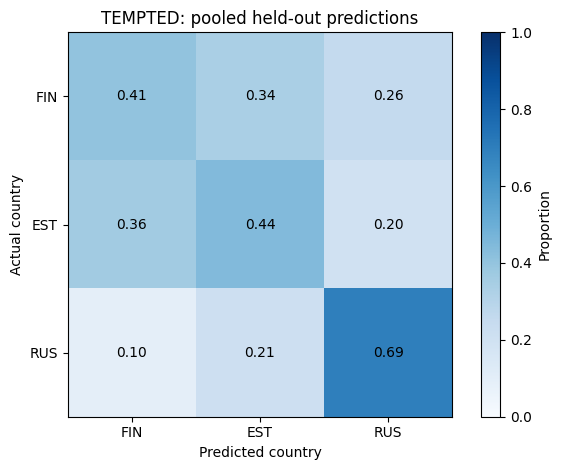

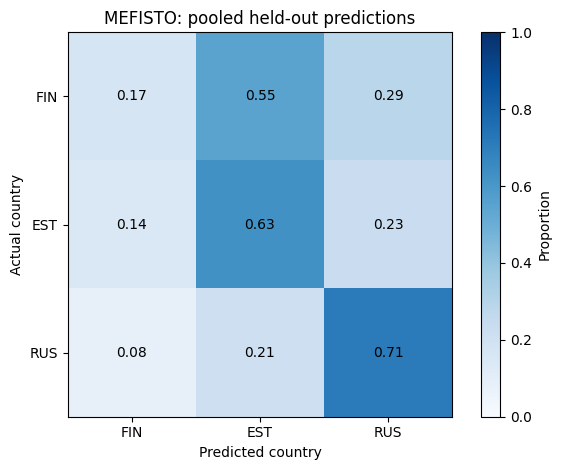

In [7]:
# plot pooled held-out confusion matrices

for method in ["TEMPTED", "MEFISTO"]:
    rows = predictions[predictions["method"] == method]

    matrix = confusion_matrix(
        rows["actual_country"],
        rows["predicted_country"],
        labels=countries,
        normalize="true",
    )

    plt.imshow(
        matrix,
        vmin=0,
        vmax=1,
        cmap="Blues",
    )

    plt.colorbar(label="Proportion")
    plt.xticks(range(len(countries)), countries)
    plt.yticks(range(len(countries)), countries)
    plt.xlabel("Predicted country")
    plt.ylabel("Actual country")
    plt.title(f"{method}: pooled held-out predictions")

    for i in range(len(countries)):
        for j in range(len(countries)):
            plt.text(
                j,
                i,
                f"{matrix[i, j]:.2f}",
                ha="center",
                va="center",
            )

    save(f"{method.lower()}_test_confusion.png")
